# 05 - EIS with PyBaMM

PyBaMM includes a frequency-domain EIS workflow through `pybamm.EISSimulation`.
For EIS, the lithium-ion model needs the option `{"surface form": "differential"}`.

Docs:

- EIS simulation example: https://docs.pybamm.org/en/stable/source/examples/notebooks/simulations_and_experiments/eis-simulation.html
- Simulation API: https://docs.pybamm.org/en/stable/source/api/simulation.html

In [21]:
import os

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pybamm

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.6.2.0


## Important formulas

Small-signal impedance:

$$
Z(\omega) = \frac{\tilde V(\omega)}{\tilde I(\omega)}
$$

Nyquist plot:

$$
x = \operatorname{Re}(Z), \qquad
y = -\operatorname{Im}(Z)
$$

High frequencies emphasize fast ohmic and charge-transfer effects. Low
frequencies include slower diffusion and state redistribution effects.

In [22]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential"})
parameter_values = model.default_parameter_values

frequencies = np.logspace(-4, 4, 25)
eis_sim = pybamm.EISSimulation(model, parameter_values=parameter_values)
eis_solution = eis_sim.solve(frequencies, initial_soc=0.5)

print("Available EIS outputs:", list(eis_solution.data.keys()))

Available EIS outputs: ['Frequency [Hz]', 'Impedance [Ohm]', 'Z_re [Ohm]', 'Z_im [Ohm]']


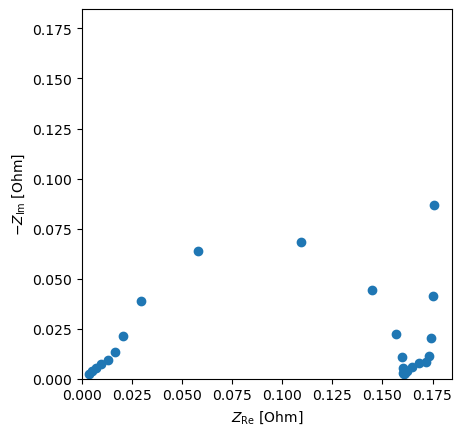

In [23]:
eis_solution.nyquist_plot(show_plot=False)
plt.show()

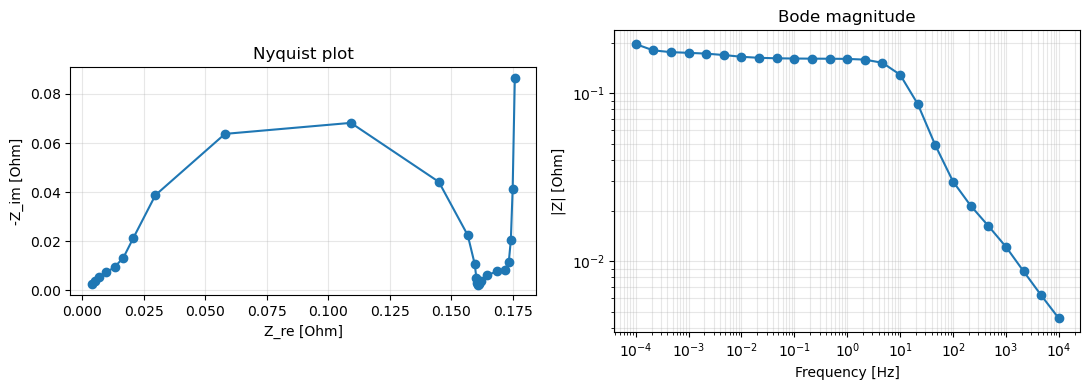

In [24]:
z = eis_solution["Impedance [Ohm]"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(eis_solution["Z_re [Ohm]"], -eis_solution["Z_im [Ohm]"], "o-")
axes[0].set_xlabel("Z_re [Ohm]")
axes[0].set_ylabel("-Z_im [Ohm]")
axes[0].set_title("Nyquist plot")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)

axes[1].loglog(eis_solution["Frequency [Hz]"], np.abs(z), "o-")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|Z| [Ohm]")
axes[1].set_title("Bode magnitude")
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## SOC sweep

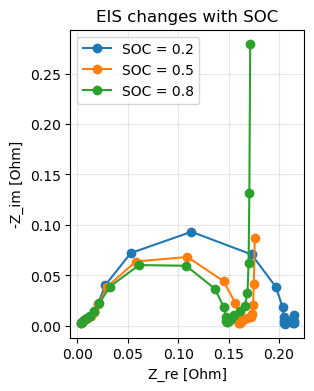

In [25]:
soc_values = [0.2, 0.5, 0.8]

plt.figure(figsize=(5, 4))
for soc in soc_values:
    result = eis_sim.solve(frequencies, initial_soc=soc)
    plt.plot(
        result["Z_re [Ohm]"],
        -result["Z_im [Ohm]"],
        "o-",
        label=f"SOC = {soc:.1f}",
    )

plt.xlabel("Z_re [Ohm]")
plt.ylabel("-Z_im [Ohm]")
plt.title("EIS changes with SOC")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Teaching prompts

- Compare DFN with `SPM` and `SPMe` using the same `surface form` option.
- Increase the low-frequency range and discuss why low-frequency EIS is slow experimentally.
- Ask which parts of the Nyquist plot might map to ohmic, charge-transfer, and diffusion behavior.